In [ ]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import numpy as np
import sys
import pandas as pd
import torch.cuda
from openpyxl import load_workbook, Workbook

notebook_dir = os.path.abspath('')

root_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

from stable_baselines3 import TD3
from aml_project.environments.lettuce_greenhouse import LettuceGreenhouse
from aml_project.common.plot_gh_variables import create_trajectory_figure, plot_trajectory

# Define the exact coefficients from Morcego et al. (2023)
# reward_coefs = [c_r1 (growth), c_r_co2_2 (CO2 in-bounds)]
custom_reward_coefs = np.array([16.0, 0.0005])

# penalty_coefs = [c_r_u1 (CO2), c_r_u2 (Vent), c_r_u3 (Heat), c_r_co2_1 (CO2 bounds), c_r_T1 (Temp low), c_r_T2 (Temp high)]
custom_penalty_coefs = np.array([4.5360e-4, 0.0075, 8.5725e-4, 0.1, 0.001, 0.0005])

weather_file = root_dir + r'\aml_project\environments\weather\outdoorWeatherWurGlas2014.mat'

env = LettuceGreenhouse(
    weather_data_dir=weather_file, 
    reward_coefs=custom_reward_coefs, 
    penalty_coefs=custom_penalty_coefs,
    n_days=100
)



In [3]:

# Initialize the Soft Actor-Critic model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TD3("MlpPolicy", env, verbose=1, learning_rate=1e-3, batch_size=64, device='cpu')
model.learn(total_timesteps=100000) 
model.save("td3_lettuce_greenhouse")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 192       |
|    ep_rew_mean     | -1.21e+07 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 199       |
|    time_elapsed    | 3         |
|    total_timesteps | 768       |
| train/             |           |
|    actor_loss      | 1.04e+05  |
|    critic_loss     | 4.67e+07  |
|    learning_rate   | 0.001     |
|    n_updates       | 667       |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 192       |
|    ep_rew_mean     | -1.21e+07 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 157       |
|    time_elapsed    | 9         |
|    total_timesteps | 1536      |
| train/             |           |
|    actor_loss      | 2e+05   

In [7]:
# We must reset the environment before testing
from aml_project.common.helper_functions import weather2ppmrh


obs, info = env.reset()

done = False
truncated = False

# Initialize arrays to store measurements, actions, and rewards
y = np.zeros((env.N+1, env.ny))
u = np.zeros((env.N, env.action_space.shape[0]))
rewards = np.zeros((env.N, 1))

# Set initial state and action
y[0] = env.g()
env.prev_action = np.zeros(env.action_space.shape[0])

# Initialize loop variables
k = 0
terminated = False
done = False

# Generate trajectory until termination
while not terminated and not done:
    # Predict the action using the trained model
    action, _states = model.predict(obs, deterministic=True)
    # Take the action in the environment
    obs, reward, done, truncated, info = env.step(action)

    # Store the previous action
    u[k] = env.prev_action

    # Store the observation as a measurement
    y[k+1] = obs[:env.ny]

    # Accumulate the reward
    rewards[k] += reward

    # Increment the step counter
    k += 1

# Return the generated trajectory
y = y[:env.N]
d = weather2ppmrh(env.d[:env.N])
u = u[:env.N]
r = rewards[:env.N]


Plotting results...


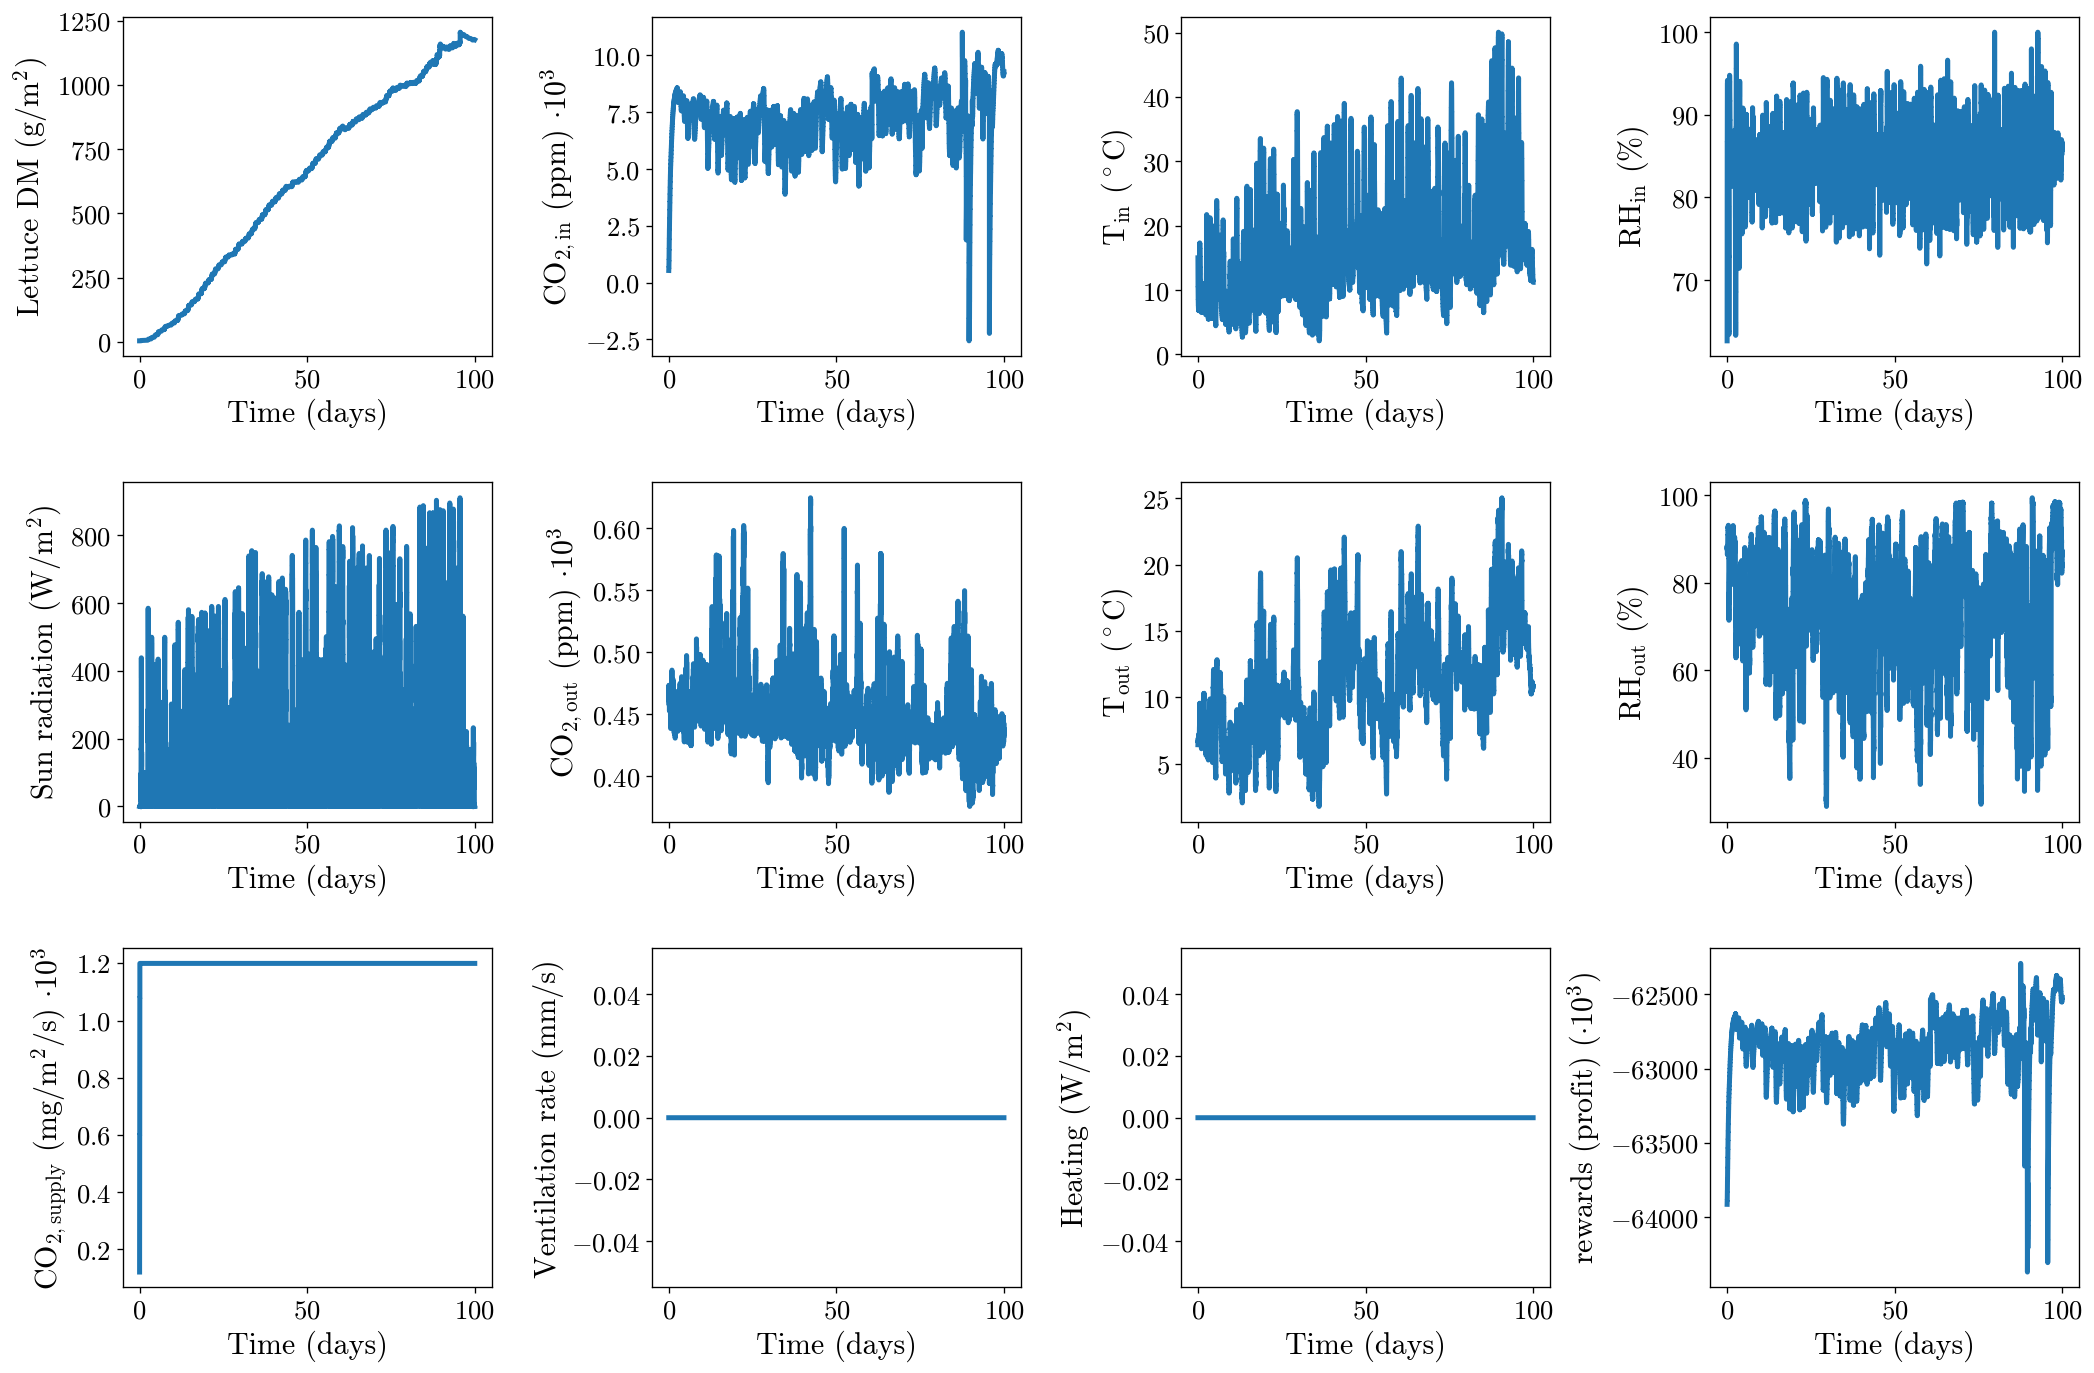

In [8]:
print("Plotting results...")

nvars = 12
# plot the resulting trajectory
n_per_day = int(24*3600/env.h) # control frequency per day
label= 'Trained SAC policy'
trajectory = np.concatenate((y, d, u, r), axis=1)
fig, axes = create_trajectory_figure(nvars, env.L, env.h, env.c, None, None)
fig, axes = plot_trajectory(fig, axes, trajectory, env.L, env.h, env.c, 0, env.n_days, n_per_day, label)

In [10]:
def run_zero_input_baseline(env):
    # First heuristic where we hold all inputs at 0 (minimum)
    obs, info = env.reset()
    terminated = False
    done = False
    
    # Action space is scaled between -1 and 1. -1 corresponds to 0 physical input.
    zero_action = np.array([-1.0, -1.0, -1.0], dtype=np.float32) 
    
    while not terminated and not done:
        obs, reward, terminated, truncated, info = env.step(zero_action)
        
    return info['profit'].sum(), info


def run_heuristic_baseline(env):
    # Second heuristic where we dose CO2 if below 850 ppm, heat if below 16C, and ventilate if above 19.5C
    obs, info = env.reset()
    terminated = False
    done = False
    
    while not terminated and not done:
        # obs[:4] corresponds to greenhouse measurements: [dry_weight, co2_ppm, temp_c, rh]
        co2_ppm = obs[1]
        temp_c = obs[2]
        
        # CO2 Dosing 
        co2_act = 0.2 if co2_ppm < 850 else -1.0
        
       # Temperature 
        if temp_c < 16.0:
            heat_act = 0.5  # Turn on heating
            vent_act = -1.0 # Close vents to trap heat
        elif temp_c > 19.5:
            heat_act = -1.0 # Turn off heating
            vent_act = 0.3  # Open vents to cool down
        else:
            heat_act = -1.0 # Optimal band: do nothing
            vent_act = -1.0
            
        action = np.array([co2_act, vent_act, heat_act], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        
    return info['profit'].sum(), info

In [11]:
# Actual evaluation of the trained SAC agent
sac_total_profit = info['profit'].sum()

zero_profit, zero_info = run_zero_input_baseline(env)
heuristic_profit, heuristic_info = run_heuristic_baseline(env)

print(f"--- Cumulative Profit Comparison ---")
print(f"Zero-Input Baseline Profit : {zero_profit:.2f}")
print(f"Heuristic Baseline Profit  : {heuristic_profit:.2f}")
print(f"Trained SAC Agent Profit   : {sac_total_profit:.2f}")

--- Cumulative Profit Comparison ---
Zero-Input Baseline Profit : 28466.95
Heuristic Baseline Profit  : 13746.28
Trained SAC Agent Profit   : 18756.08
